# Predictive Maintenance for wind Turbine 

## Presentation of this project

This project relies on three complementary datasets from a wind turbine supervision system:

1. **SCADA Dataset**: contains all physical measurements collected in real time (wind speed, power output, temperatures, etc.) \
2. **Status Dataset**: describes the operational state of the turbine at each moment (running, stopped, under maintenance, etc.)\
3. **Fault Dataset**: groups together alarm trigger records and detected faults on the turbine

## Objectives

This project pursues two main objectives:

1. **Anomaly Detection**: identify in real time any abnormal behavior of the turbine from SCADA data
2. **Predictive Maintenance**: anticipate failures before they occur, in order to reduce intervention costs and unplanned downtime

```


In [6]:
import pandas as pd
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np

In [7]:
df_scada=pd.read_csv(r"/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/scada_data.csv")
df_status=pd.read_csv("/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/status_data.csv")
df_fault=pd.read_csv("/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/datasets/fault_data.csv")

# 1. Dataset SACDA

In [8]:
df_scada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49027 entries, 0 to 49026
Data columns (total 66 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   DateTime                                           49027 non-null  object 
 1   Time                                               49027 non-null  int64  
 2   Error                                              49027 non-null  int64  
 3   WEC: ava. windspeed                                49027 non-null  float64
 4   WEC: max. windspeed                                49027 non-null  float64
 5   WEC: min. windspeed                                49027 non-null  float64
 6   WEC: ava. Rotation                                 49027 non-null  float64
 7   WEC: max. Rotation                                 49027 non-null  float64
 8   WEC: min. Rotation                                 49027 non-null  float64
 9   WEC: a

In [9]:
# supprimer les rebondance
df_scada_clean=df_scada.drop(['DateTime','Time'],axis=1)
df_scada_clean=df_scada_clean.select_dtypes(include=['number']).drop(['Error'],axis=1) # selectionner que lmes features numeriques et la supression de la target 
df_scada_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49027 entries, 0 to 49026
Data columns (total 63 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   WEC: ava. windspeed                                49027 non-null  float64
 1   WEC: max. windspeed                                49027 non-null  float64
 2   WEC: min. windspeed                                49027 non-null  float64
 3   WEC: ava. Rotation                                 49027 non-null  float64
 4   WEC: max. Rotation                                 49027 non-null  float64
 5   WEC: min. Rotation                                 49027 non-null  float64
 6   WEC: ava. Power                                    49027 non-null  int64  
 7   WEC: max. Power                                    49027 non-null  int64  
 8   WEC: min. Power                                    49027 non-null  int64  
 9   WEC: a

In [10]:
# supprimer les colonnes uniques
df_scada_clean=df_scada_clean.loc[:,df_scada_clean.nunique() > 1]

In [11]:
corr_matrix=df_scada_clean.corr().abs()
# on construit un masque 
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)) # on 'applique un masque triagulaire dans lequel on garde que le traingle superieur sans la diagonale car la matrice de corrélation est symetrique
# la condition 
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)] # selctionner les varibales à supprimer on garde que les colonnes qui sont corréles , on supprime une on garde l'autre pour eviter la redondance (on met 0.95 seules les colonnes quasi- identique sont supprimées )
df_scada_clean = df_scada_clean.drop(to_drop, axis=1) # appliquer le masque
df_scada_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49027 entries, 0 to 49026
Data columns (total 33 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   WEC: ava. windspeed                                49027 non-null  float64
 1   WEC: min. windspeed                                49027 non-null  float64
 2   WEC: ava. Rotation                                 49027 non-null  float64
 3   WEC: ava. Power                                    49027 non-null  int64  
 4   WEC: min. Power                                    49027 non-null  int64  
 5   WEC: ava. Nacel position including cable twisting  49027 non-null  int64  
 6   WEC: Operating Hours                               49027 non-null  int64  
 7   WEC: Production minutes                            49027 non-null  int64  
 8   WEC: ava. reactive Power                           49027 non-null  int64  
 9   WEC: m

In [ ]:
rename_dict = {
    'WEC: ava. windspeed': 'WindSpeed_avg',
    'WEC: min. windspeed': 'WindSpeed_min',
    'WEC: ava. Rotation': 'Rotation_avg',
    'WEC: ava. Power': 'Power_avg',
    'WEC: min. Power': 'Power_min',
    'WEC: ava. Nacel position including cable twisting': 'Nacelle_pos_twist',
    'WEC: Production minutes': 'Prod_minutes',
    'WEC: ava. reactive Power': 'ReactivePower_avg',
    'WEC: max. reactive Power': 'ReactivePower_max',
    'WEC: ava. available P from wind': 'AvailablePower_wind',
    'WEC: Operating Hours': 'Operating_Hours',
    'WEC: ava. blade angle A': 'BladeA_angle',
    'Sys 1 inverter 1 cabinet temp.': 'Inv1_1_temp',
    'Sys 1 inverter 3 cabinet temp.': 'Inv1_3_temp',
    'Sys 1 inverter 5 cabinet temp.': 'Inv1_5_temp',
    'Sys 1 inverter 7 cabinet temp.': 'Inv1_7_temp',
    'Sys 2 inverter 5 cabinet temp.': 'Inv2_5_temp',
    'Spinner temp.': 'Spinner_temp',
    'Front bearing temp.': 'FrontBearing_temp',
    'Rear bearing temp.': 'RearBearing_temp',
    'Pitch cabinet blade A temp.': 'PitchBladeA_temp',
    'Pitch cabinet blade C temp.': 'PitchBladeC_temp',
    'Rotor temp. 1': 'Rotor1_temp',
    'Stator temp. 1': 'Stator1_temp',
    'Nacelle ambient temp. 1': 'NacelleAmbient1_temp',
    'Nacelle temp.': 'Nacelle_temp',
    'Main carrier temp.': 'MainCarrier_temp',
    'Rectifier cabinet temp.': 'Rectifier_temp',
    'Yaw inverter cabinet temp.': 'YawInv_temp',
    'Tower temp.': 'Tower_temp',
    'Transformer temp.': 'Transformer_temp',
    'RTU: ava. Setpoint 1': 'RTU_Setpoint1',
    'Inverter std dev': 'Inv_stddev'
}


df_scada_clean= df_scada_clean.rename(columns=rename_dict)
df_scada_clean.columns


Index(['WindSpeed_avg', 'WindSpeed_min', 'Rotation_avg', 'Power_avg',
       'Power_min', 'Nacelle_pos_twist', 'Operating_Hours', 'Prod_minutes',
       'ReactivePower_avg', 'ReactivePower_max', 'AvailablePower_wind',
       'BladeA_angle', 'Inv1_1_temp', 'Inv1_3_temp', 'Inv1_5_temp',
       'Inv1_7_temp', 'Inv2_5_temp', 'Spinner_temp', 'FrontBearing_temp',
       'RearBearing_temp', 'PitchBladeA_temp', 'PitchBladeC_temp',
       'Rotor1_temp', 'Stator1_temp', 'NacelleAmbient1_temp', 'Nacelle_temp',
       'MainCarrier_temp', 'Rectifier_temp', 'YawInv_temp', 'Tower_temp',
       'Transformer_temp', 'RTU_Setpoint1', 'Inv_stddev'],
      dtype='object')

In [ ]:
#### regroupenement of the features 

# Wind / Rotor
aoraudynamic_features = [
    'WindSpeed_avg', 'WindSpeed_min',
    'Rotation_avg', 'BladeA_angle', 'Nacelle_pos_twist',
    'Power_avg', 'Power_min',
    'ReactivePower_avg', 'ReactivePower_max',
    'AvailablePower_wind', 'Prod_minutes'
]

#Temperatures / Electrical Systems 
temp_features = [
    'Inv1_1_temp', 'Inv1_3_temp', 'Inv1_5_temp', 'Inv1_7_temp',
    'Inv2_5_temp', 'Spinner_temp', 'FrontBearing_temp', 'RearBearing_temp',
    'PitchBladeA_temp', 'PitchBladeC_temp', 'Rotor1_temp', 'Stator1_temp',
    'NacelleAmbient1_temp', 'Nacelle_temp', 'MainCarrier_temp', 'Rectifier_temp',
    'YawInv_temp', 'Tower_temp', 'Transformer_temp'
]
# Control 
control_features = [
    'RTU_Setpoint1', 'Inv_stddev'
]

status_features = [
    'Prod_minutes',
    'Error'  
]



In [35]:
# add the colonms : Time et traget
df_scada_clean['DateTime'] = pd.to_datetime(df_scada['DateTime'])
df_scada_clean['Error']=df_scada['Error']

In [15]:
df_scada_clean.head(n=3)

,WindSpeed_avg,WindSpeed_min,Rotation_avg,Power_avg,Power_min,Nacelle_pos_twist,Operating_Hours,Prod_minutes,ReactivePower_avg,ReactivePower_max,...,Nacelle_temp,MainCarrier_temp,Rectifier_temp,YawInv_temp,Tower_temp,Transformer_temp,RTU_Setpoint1,Inv_stddev,DateTime,Error
0,6.9,2.9,0.0,0,0,640,881,6,0,0,...,14,13,24,20,14,34,2501,1.103713,2014-05-01 00:00:00,0
1,5.3,1.6,0.0,0,0,640,881,6,0,0,...,13,13,24,20,14,34,2501,1.103713,2014-05-01 00:09:00,0
2,5.0,1.4,0.0,0,0,640,881,6,0,0,...,13,13,24,20,14,34,2501,1.103713,2014-05-01 00:20:00,0


### 1.1 Dataset Verification

<Axes: >

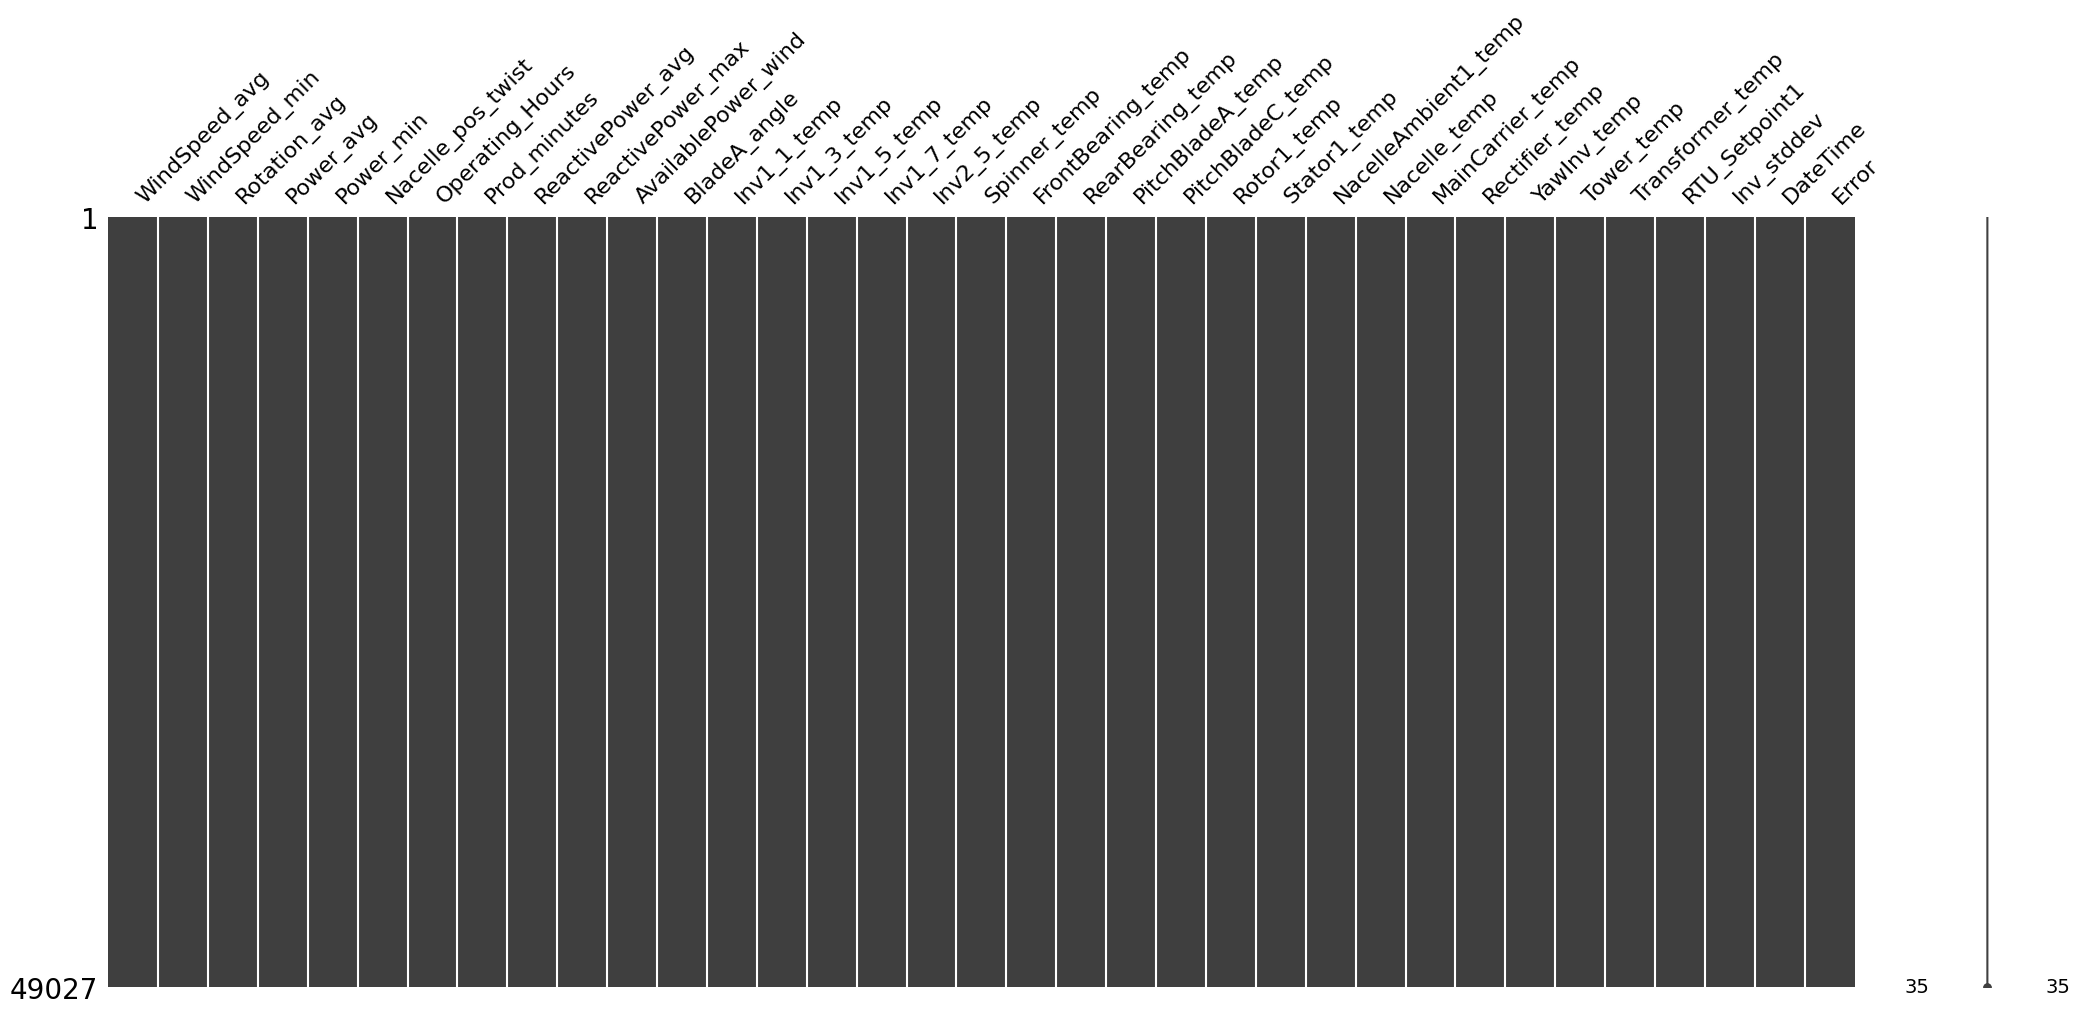

In [16]:
msno.matrix(df_scada_clean) # valeurs manquantes

In [17]:
print(df_scada_clean[aoraudynamic_features].isnull().sum().sum())
# il y'a pas de NaN 

0


### 1.2 Target Distribution

In [18]:
df_scada_clean['Error'].value_counts()
df_scada_clean_normale=df_scada_clean[df_scada_clean['Error']==0]
df_scada_clean_anormale=df_scada_clean[df_scada_clean['Error']!=0]

Text(0.5, 0, 'Traget=>Error')

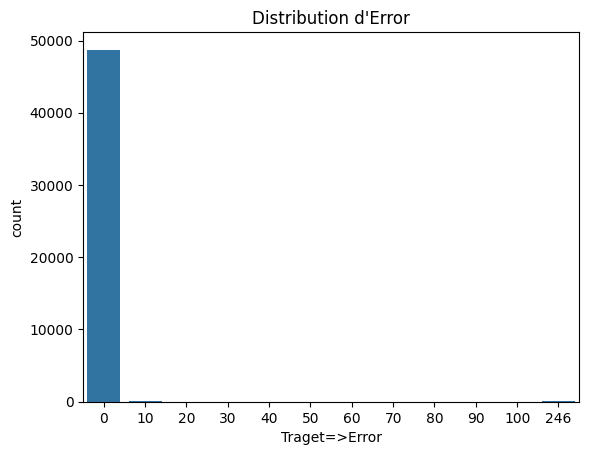

In [19]:
# Exploration de la target labéllisé automatiquement dans le SCADA
sns.countplot(x='Error', data=df_scada_clean) # 0 : normal , =! 0 : erreur
plt.title("Distribution d'Error")
plt.xlabel("Traget=>Error")


Text(0.5, 0, 'Type Error')

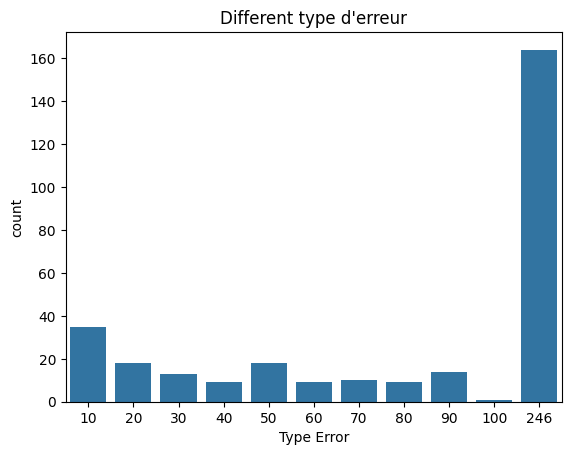

In [20]:
sns.countplot(x='Error', data=df_scada_clean_anormale)
plt.title("Different type d'erreur")
plt.xlabel("Type Error")


## 1.3 Aerodynamic Features Exploration

/tmp/ipykernel_1384/909882884.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend()


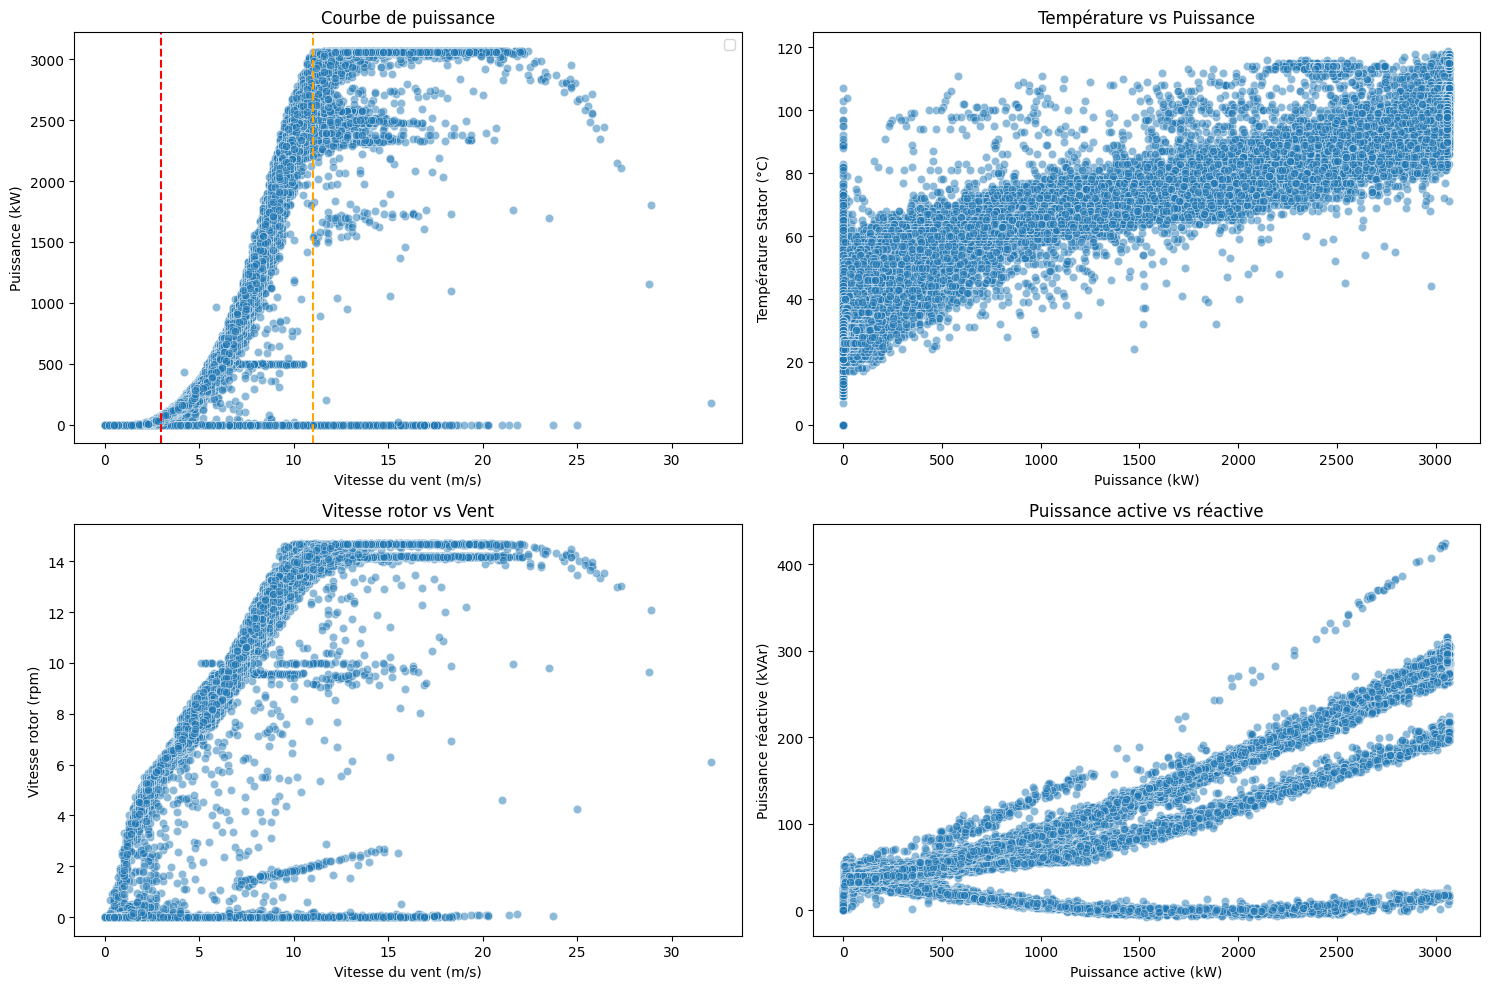

In [21]:

# Configuration pour des plots multiples
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Vitesse du vent vs Puissance (votre plot actuel amélioré)
sns.scatterplot(x=df_scada_clean['WindSpeed_avg'], y=df_scada_clean['Power_avg'], 
                alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_xlabel('Vitesse du vent (m/s)')
axes[0, 0].set_ylabel('Puissance (kW)')
axes[0, 0].set_title('Courbe de puissance')
axes[0, 0].axvline(3, color='red', linestyle='--')
axes[0, 0].axvline(11, color='orange', linestyle='--')
axes[0, 0].legend()

# Plot 2: Température du générateur (exemple mécanique)
# Remplacez 'GenTemp_avg' par le nom de votre colonne
sns.scatterplot(x=df_scada_clean['Power_avg'], y=df_scada_clean['Stator1_temp'],
                alpha=0.5, ax=axes[0, 1])
axes[0, 1].set_xlabel('Puissance (kW)')
axes[0, 1].set_ylabel('Température Stator (°C)')
axes[0, 1].set_title('Température vs Puissance')

# Plot 3: Vitesse du rotor (exemple mécanique)
sns.scatterplot(x=df_scada_clean['WindSpeed_avg'], y=df_scada_clean['Rotation_avg'],
                alpha=0.5, ax=axes[1, 0])
axes[1, 0].set_xlabel('Vitesse du vent (m/s)')
axes[1, 0].set_ylabel('Vitesse rotor (rpm)')
axes[1, 0].set_title('Vitesse rotor vs Vent')

# Plot 4: Puissance active vs réactive (exemple électrique)
sns.scatterplot(x=df_scada_clean['Power_avg'], y=df_scada_clean['ReactivePower_avg'],
                alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_xlabel('Puissance active (kW)')
axes[1, 1].set_ylabel('Puissance réactive (kVAr)')
axes[1, 1].set_title('Puissance active vs réactive')

plt.tight_layout()
plt.show()

### 1.4 Separation into Modes

In [22]:
def classify_mode(row):
    if row['Power_avg'] < 10 and row['Rotation_avg'] < 5: # vent utilise pour l'eolienne entre 4-12 
        return 0  # Turbine arrêtée
    elif row['WindSpeed_avg'] < 4: 
        return 1  # Vent faible
    elif row['WindSpeed_avg'] > 12: # vent fort est potentiellement tres dangereux 
        return 3  # High wind / regulation le mode stable quand le vent il dépasse pascertain vitesse 
    else:
        return 2  # Production normale

df_scada_clean['Mode'] = df_scada_clean.apply(classify_mode, axis=1)
df_scada_clean['Mode'].value_counts()

Mode
2    30594
0     7279
1     6944
3     4210
Name: count, dtype: int64

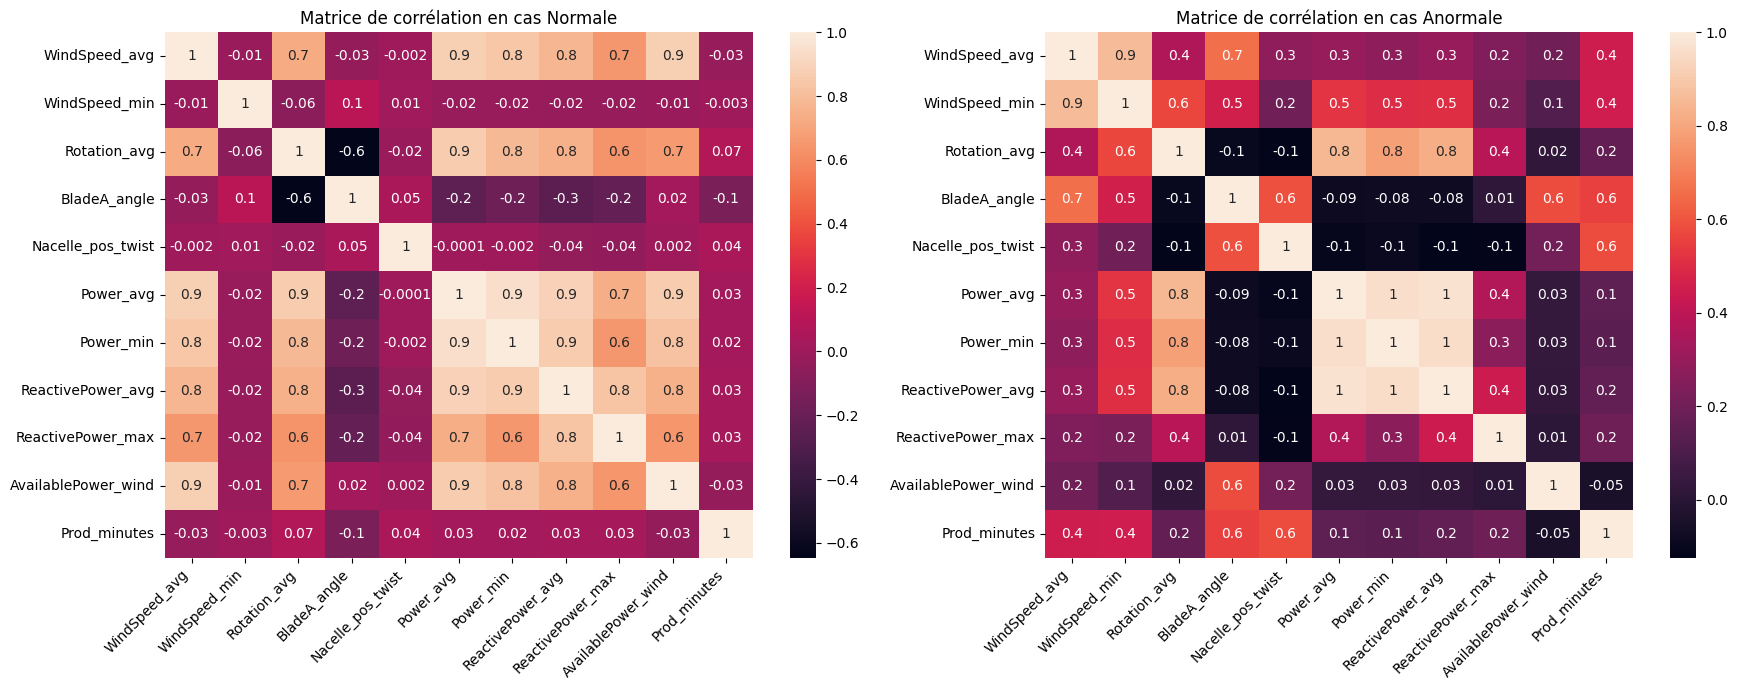

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normale
corr_wind_normale = df_scada_clean_normale[aoraudynamic_features].corr()
sns.heatmap(corr_wind_normale, annot=True, fmt='.1g', ax=axes[0])
axes[0].set_title("Matrice de corrélation en cas Normale")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Anormale
corr_wind_anormale = df_scada_clean_anormale[aoraudynamic_features].corr()
sns.heatmap(corr_wind_anormale, annot=True, fmt='.1g', ax=axes[1])
axes[1].set_title("Matrice de corrélation en cas Anormale")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

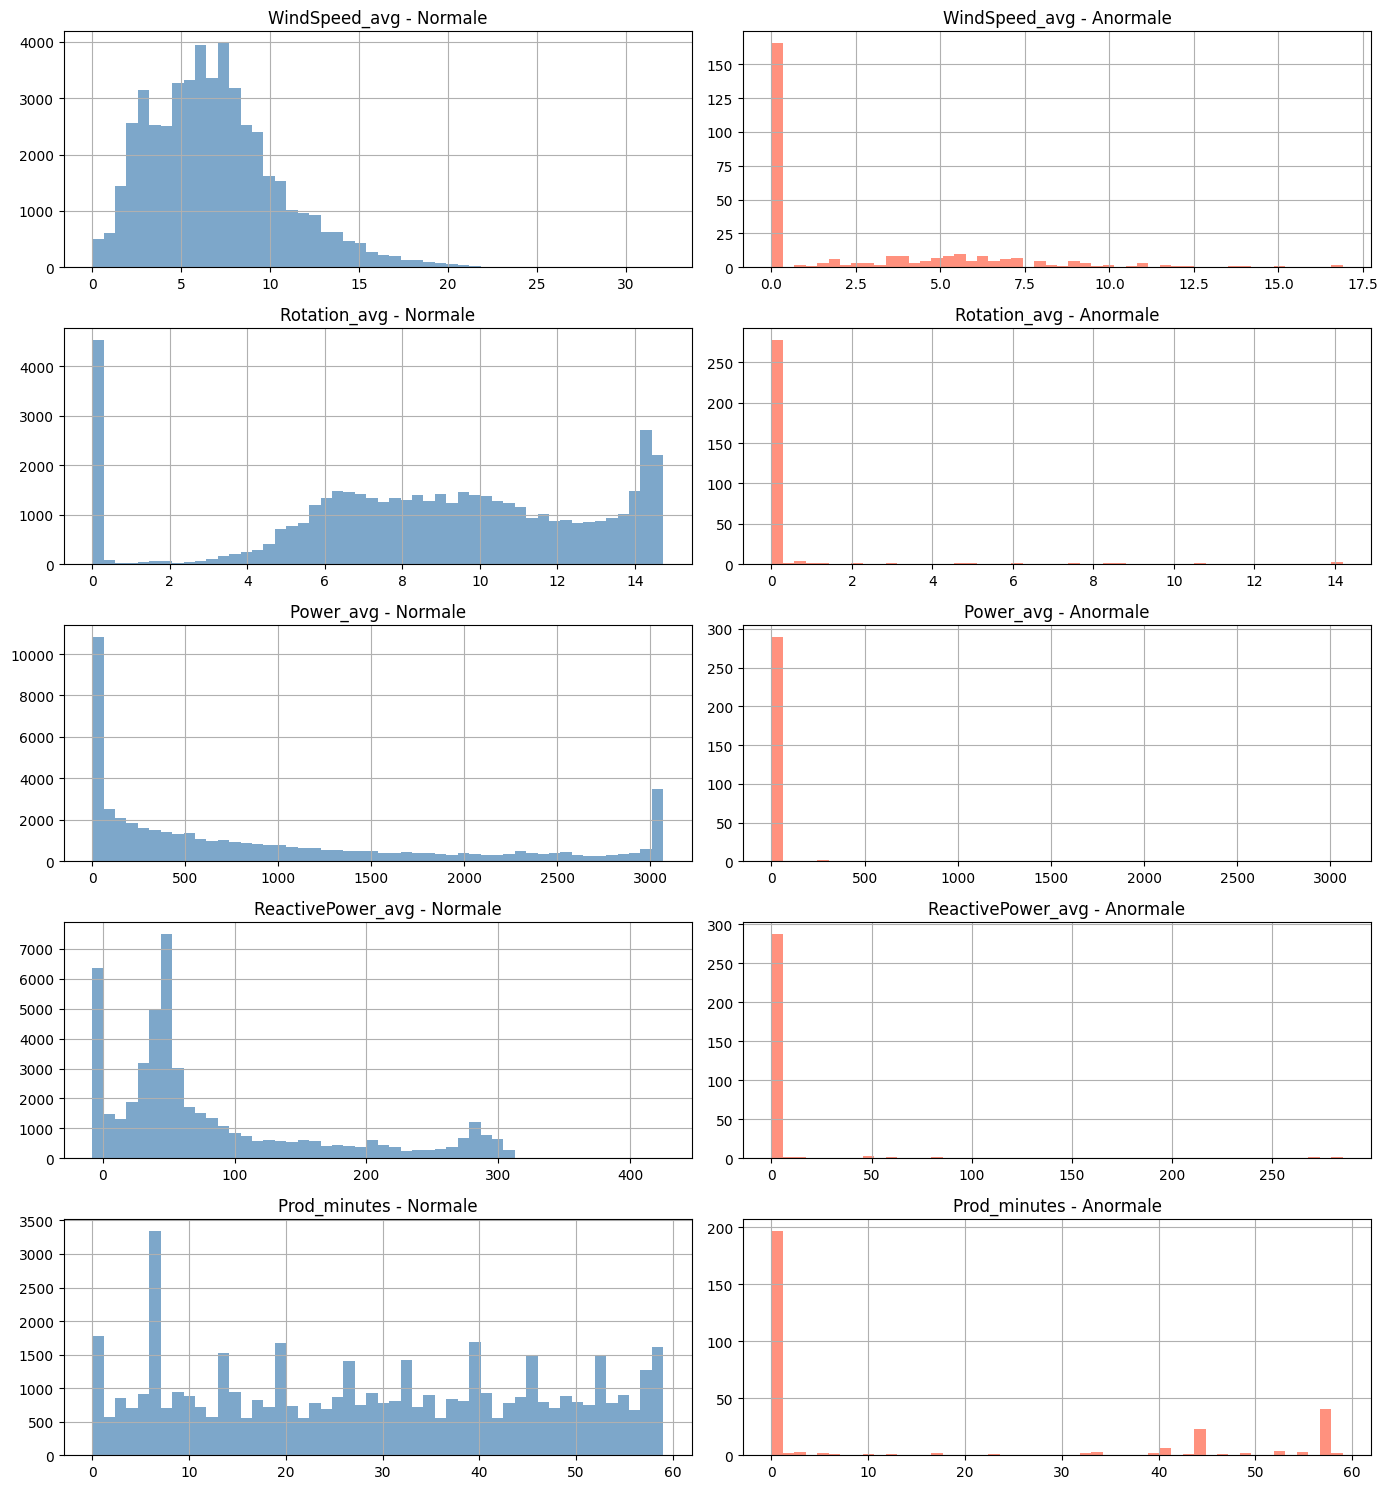

In [24]:
aoraudynamic_features = [
    'WindSpeed_avg',
    'Rotation_avg',
    'Power_avg', 
    'ReactivePower_avg', 
    'Prod_minutes'
]
fig, axes = plt.subplots(len(aoraudynamic_features), 2, figsize=(14, len(aoraudynamic_features)*3))

for i, feature in enumerate(aoraudynamic_features):
    df_scada_clean_normale[feature].hist(ax=axes[i,0], bins=50, color='steelblue', alpha=0.7)
    axes[i,0].set_title(f"{feature} - Normale")
    
    df_scada_clean_anormale[feature].hist(ax=axes[i,1], bins=50, color='tomato', alpha=0.7)
    axes[i,1].set_title(f"{feature} - Anormale")

plt.tight_layout()
plt.show()

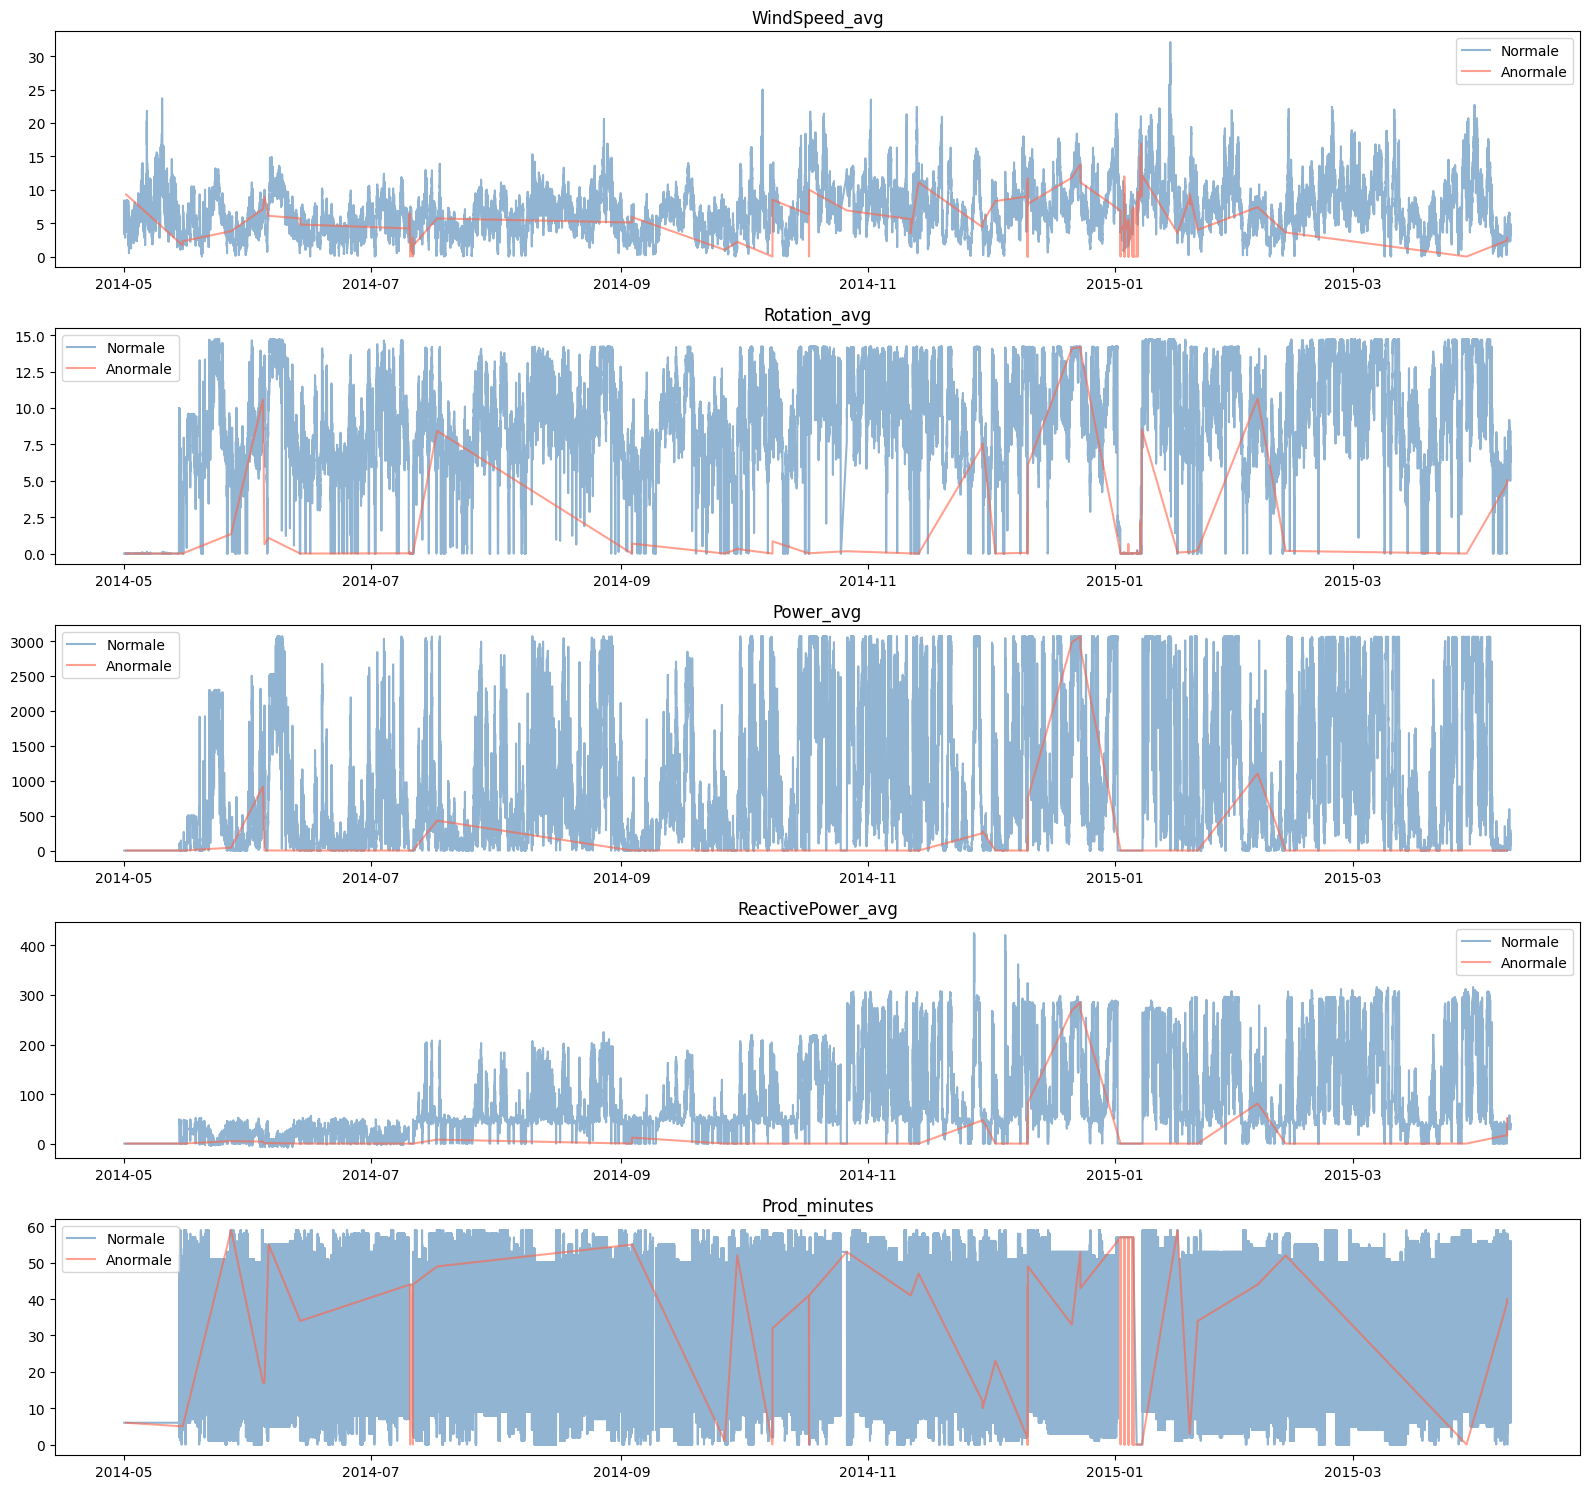

In [25]:
fig, axes = plt.subplots(len(aoraudynamic_features), 1, figsize=(16, len(aoraudynamic_features)*3))

for i, feature in enumerate(aoraudynamic_features):
    axes[i].plot(df_scada_clean_normale['DateTime'], df_scada_clean_normale[feature], 
                 color='steelblue', alpha=0.6, label='Normale')
    axes[i].plot(df_scada_clean_anormale['DateTime'], df_scada_clean_anormale[feature], 
                 color='tomato', alpha=0.6, label='Anormale')
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

## 1.5 Features Engineering

In [36]:
# Create new features
df_scada_clean['Delta_Rotor_Stator'] = df_scada_clean['Rotor1_temp'] - df_scada_clean['Stator1_temp']
# stator_temp: the fixed part of the rotor
# rotor_temp: the rotating part ==> the rotor is slightly hotter than the stator
# delta interpretation: low and constant => normal system state | high delta => rotor cooling problem or excessive friction

df_scada_clean['Inv_mean_temp'] = df_scada_clean[['Inv1_1_temp', 'Inv1_3_temp', 'Inv2_5_temp']].mean(axis=1)
# Inv = inverters = power converters, transform the electricity produced
# these converters are very sensitive to load and reactive power

df_scada_clean['Bearing_diff'] = df_scada_clean['RearBearing_temp'] - df_scada_clean['FrontBearing_temp']
# RearBearing_temp: rear bearing
# FrontBearing_temp: front bearing
# difference between the two measures mechanical asymmetry
# large difference => wear on one of the bearings

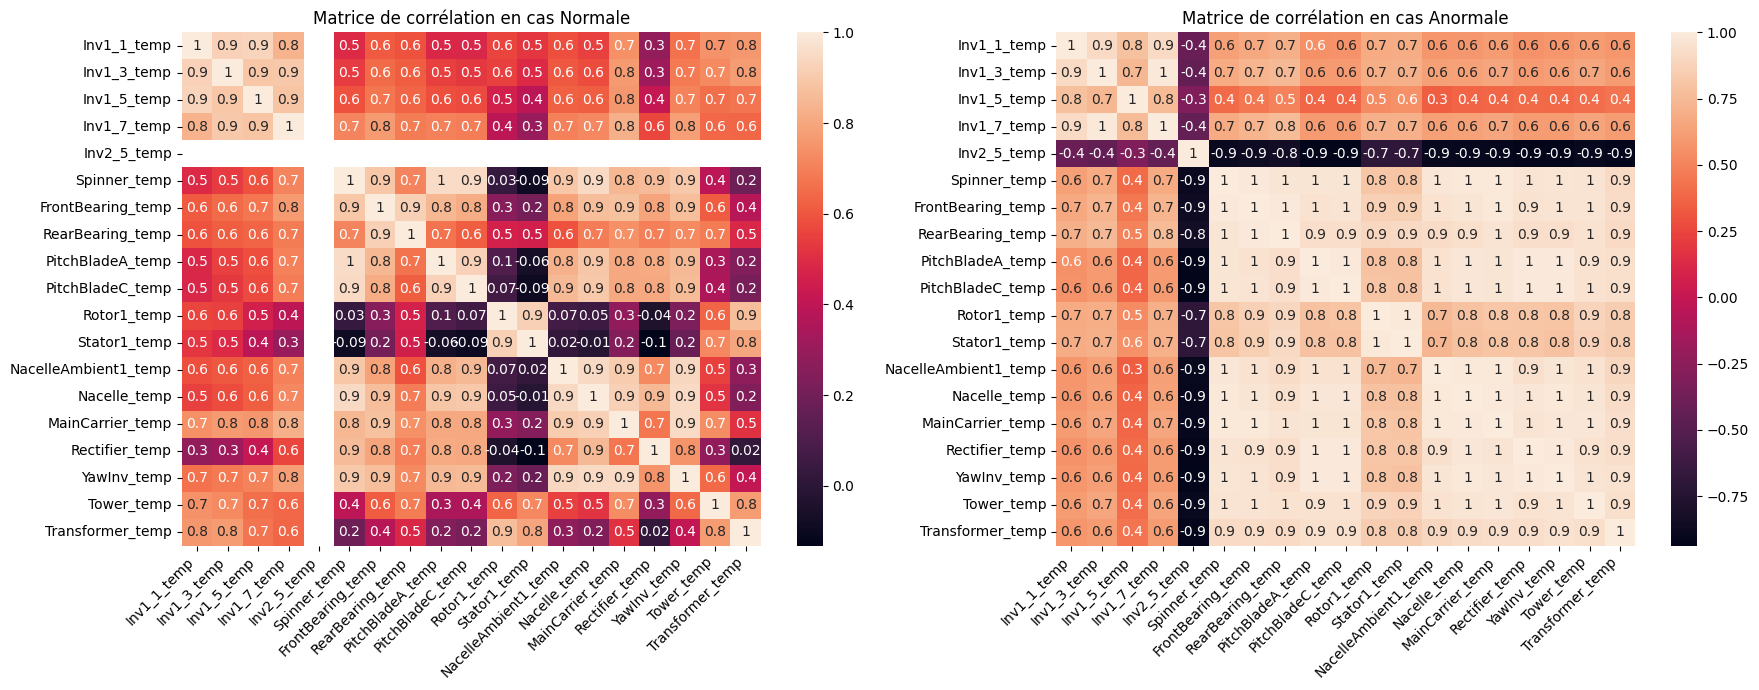

In [37]:
# Comparison of feature behavior in failure vs. normal cases
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Normale
corr_wind_normale = df_scada_clean_normale[temp_features].corr()
sns.heatmap(corr_wind_normale, annot=True, fmt='.1g', ax=axes[0])
axes[0].set_title("Matrice de corrélation en cas Normale")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Anormale
corr_wind_anormale = df_scada_clean_anormale[temp_features].corr()
sns.heatmap(corr_wind_anormale, annot=True, fmt='.1g', ax=axes[1])
axes[1].set_title("Matrice de corrélation en cas Anormale")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


# 2. Dataset Status

In [28]:
df_status

,Time,Main Status,Sub Status,Full Status,Status Text,T,Service,FaultMsg,Value0
0,24/04/2014 12:37:38,0,0,0 : 0,Turbine in operation,1,False,False,7.4
1,25/04/2014 19:27:24,71,104,71 : 104,Insulation monitoring : Insulation fault Phase U2,6,False,True,20.5
2,26/04/2014 09:30:13,8,0,8 : 0,Maintenance,6,True,False,17.1
3,26/04/2014 10:05:19,8,0,8 : 0,Maintenance,6,False,False,8.7
4,26/04/2014 10:05:25,8,0,8 : 0,Maintenance,6,True,False,10.6
...,...,...,...,...,...,...,...,...,...
1844,27/04/2015 07:26:51,0,0,0 : 0,Turbine in operation,1,False,False,7.0
1845,28/04/2015 22:14:25,26,373,26 : 373,Malfunction fan-inverter : Other control board...,6,False,False,8.1
1846,28/04/2015 22:14:53,0,2,0 : 2,Turbine operational,1,False,False,9.5
1847,28/04/2015 22:17:15,0,1,0 : 1,Turbine starting,1,False,False,11.1


In [29]:
print(" COLONNE STATUS TEXT")

print("\nStatuts les plus fréquents:")
print(df_status['Status Text'].value_counts().head(15))

# Catégorisation
print("\n📊 Catégorisation des statuts:")
operation_count = df_status['Status Text'].str.contains('operation|operational', case=False, na=False).sum()
fault_count = df_status['Status Text'].str.contains('fault|error|malfunction', case=False, na=False).sum()
maintenance_count = df_status['Status Text'].str.contains('maintenance', case=False, na=False).sum()
starting_count = df_status['Status Text'].str.contains('starting', case=False, na=False).sum()

print(f"En opération: {operation_count}")
print(f"Défauts: {fault_count}")
print(f"Maintenance: {maintenance_count}")
print(f"Démarrage: {starting_count}")


 COLONNE STATUS TEXT

Statuts les plus fréquents:
Status Text
Turbine starting                                393
Turbine in operation                            365
Turbine operational                             331
Lack of wind : Wind speed to low                167
Excitation error : Overvoltage DC-link           84
Turbine in operation during maintenance          79
Calibration of  load control                     68
Maintenance                                      64
Feeding fault : Load shedding                    47
Feeding fault : Overload chopper inverter 1      28
Turbine reset : Scada system                     23
Timeout warnmessage : Malfunction aircooling     20
Remote control PC : switched off                 16
Turbine stopped : Control cabinet                16
Remote control PC : switched on                  16
Name: count, dtype: int64

📊 Catégorisation des statuts:
En opération: 775
Défauts: 217
Maintenance: 143
Démarrage: 393


### 2.1 Categorize statuses into homogeneous categories

In [30]:
def categorize_status_improved(text):
    """
    Catégorisation améliorée des statuts SCADA
    Distingue les vraies pannes, les arrêts planifiés, et les conditions normales
    """
    
    text_lower = text.lower()
    
    # OPÉRATION NORMALE
    if any(phrase in text_lower for phrase in [
        "turbine in operation",
        "turbine operational"
    ]) and "during maintenance" not in text_lower:
        return "Normal Operation"

    # DÉMARRAGE (Normal)
    if any(phrase in text_lower for phrase in [
        "turbine starting",
        "start lead-up",
        "turbine start"
    ]):
        return "Starting"
    
    # CONDITIONS MÉTÉO (Pas une panne !)
    if any(phrase in text_lower for phrase in [
        "lack of wind",
        "wind speed to low",
        "wind speed too low",
        "storm",
        "average windspeed"
    ]):
        return "Weather Condition"
    
    #  MAINTENANCE PLANIFIÉE (Pas une panne !)
    if any(phrase in text_lower for phrase in [
        "turbine in operation during maintenance",
        "calibration",
        "maintenance",
        "test security system",
        "generator heating"
    ]):
        return "Scheduled Maintenance"
    
    # CONTRÔLE À DISTANCE (Normal)
    if any(phrase in text_lower for phrase in [
        "remote control pc : switched",
        "remote control",
        "remote display"
    ]):
        return "Remote Control"
    
    #  ARRÊTS NORMAUX / SÉCURITÉ

    if any(phrase in text_lower for phrase in [
        "turbine stopped : control cabinet",
        "turbine stopped : scada system",
        "cable twisted"  # Arrêt de sécurité normal
    ]):
        return "Normal Stop"
    
    #  RESET / REDÉMARRAGE (Peut être normal)
    if any(phrase in text_lower for phrase in [
        "turbine reset",
        "processor reset",
        "quit button"
    ]):
        return "Reset/Restart"
    
    #  DÉFAUTS RÉSEAU / ALIMENTATION
    if any(phrase in text_lower for phrase in [
        "feeding fault",
        "mains failure",
        "undervoltage",
        "overvoltage",
        "no zero crossing",
        "load shedding",
        "power failure"
    ]):
        return "Grid/Power Fault"
    
    #  DÉFAUTS ÉLECTRIQUES
    if any(phrase in text_lower for phrase in [
        "excitation error",
        "overload chopper",
        "overtemperature",
        "insulation fault",
        "data bus error",
        "control bus error"
    ]):
        return "Electrical Fault"
    
    # DÉFAUTS MÉCANIQUES
    if any(phrase in text_lower for phrase in [
        "pitch control error",
        "angle error",
        "yaw control fault",
        "air gap monitoring",
        "tower oscillation"
    ]):
        return "Mechanical Fault"
    
    #  DÉFAUTS SYSTÈMES / COMMUNICATION
    if any(phrase in text_lower for phrase in [
        "malfunction",
        "timeout",
        "no data from",
        "communication error"
    ]):
        return "System/Communication Fault"
    
    # CONDITIONS ENVIRONNEMENTALES
    if any(phrase in text_lower for phrase in [
        "turbine moist",
        "hygrostat"
    ]):
        return "Environmental Condition"
    
    # AUTRES
    return "Other"


df_status['Category'] = df_status['Status Text'].apply(categorize_status_improved)
df_status['Category'].value_counts()


Category
Normal Operation              696
Starting                      404
Scheduled Maintenance         223
Grid/Power Fault              189
Weather Condition             168
Reset/Restart                  50
Remote Control                 36
Normal Stop                    30
System/Communication Fault     28
Electrical Fault               16
Mechanical Fault                7
Environmental Condition         2
Name: count, dtype: int64

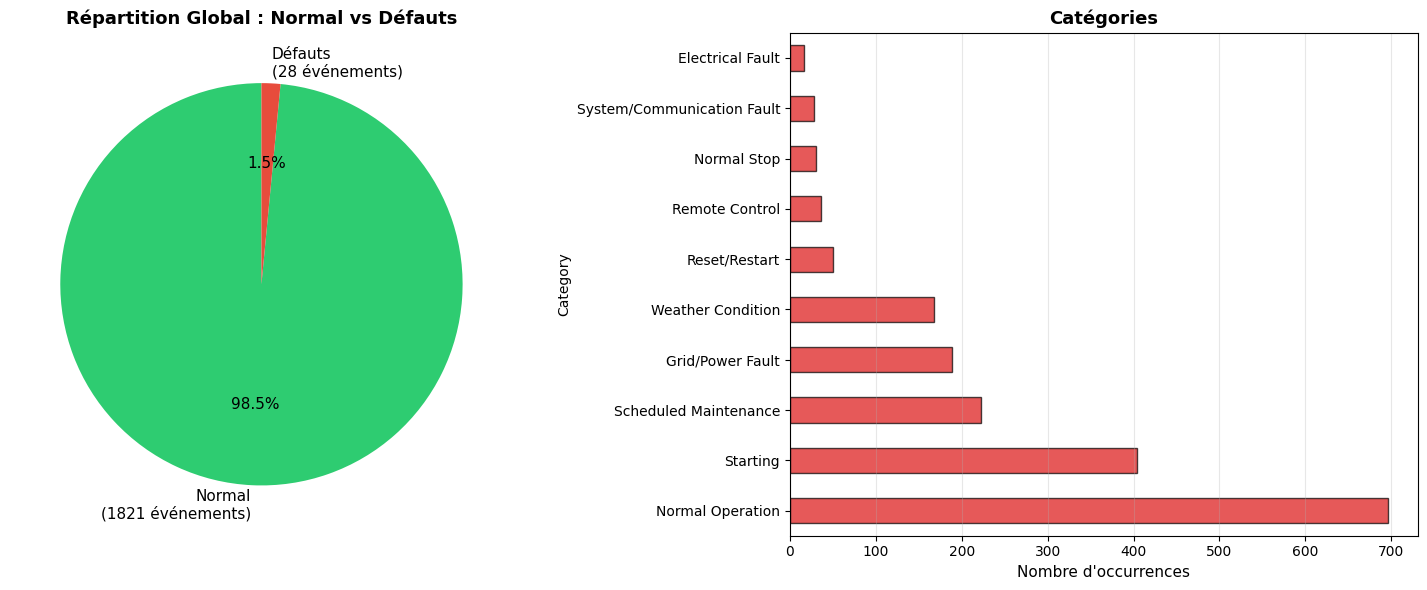

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart général
status_counts = df_status['FaultMsg'].value_counts()
labels = [f'Normal\n({status_counts[False]} événements)', 
          f'Défauts\n({status_counts[True]} événements)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(status_counts, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Répartition Global : Normal vs Défauts', 
                  fontsize=13, fontweight='bold')

# Top 10 des Status Text
top_status = df_status['Category'].value_counts().head(10)
top_status.plot(kind='barh', ax=axes[1], color="#dc1212", alpha=0.7, edgecolor='black')
axes[1].set_title('Catégories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre d\'occurrences', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 3. Dataset Fault

In [32]:
df_fault

,DateTime,Time,Fault
0,2014-05-14 14:39:44,1.400096e+09,GF
1,2014-05-14 14:50:24,1.400097e+09,GF
2,2014-05-14 14:58:56,1.400098e+09,GF
3,2014-05-14 15:09:36,1.400098e+09,GF
4,2014-05-14 15:20:16,1.400099e+09,GF
...,...,...,...
548,2015-01-14 23:00:48,1.421298e+09,AF
549,2015-01-14 23:09:20,1.421299e+09,AF
550,2015-01-15 22:50:08,1.421384e+09,AF
551,2015-01-15 23:00:48,1.421384e+09,AF


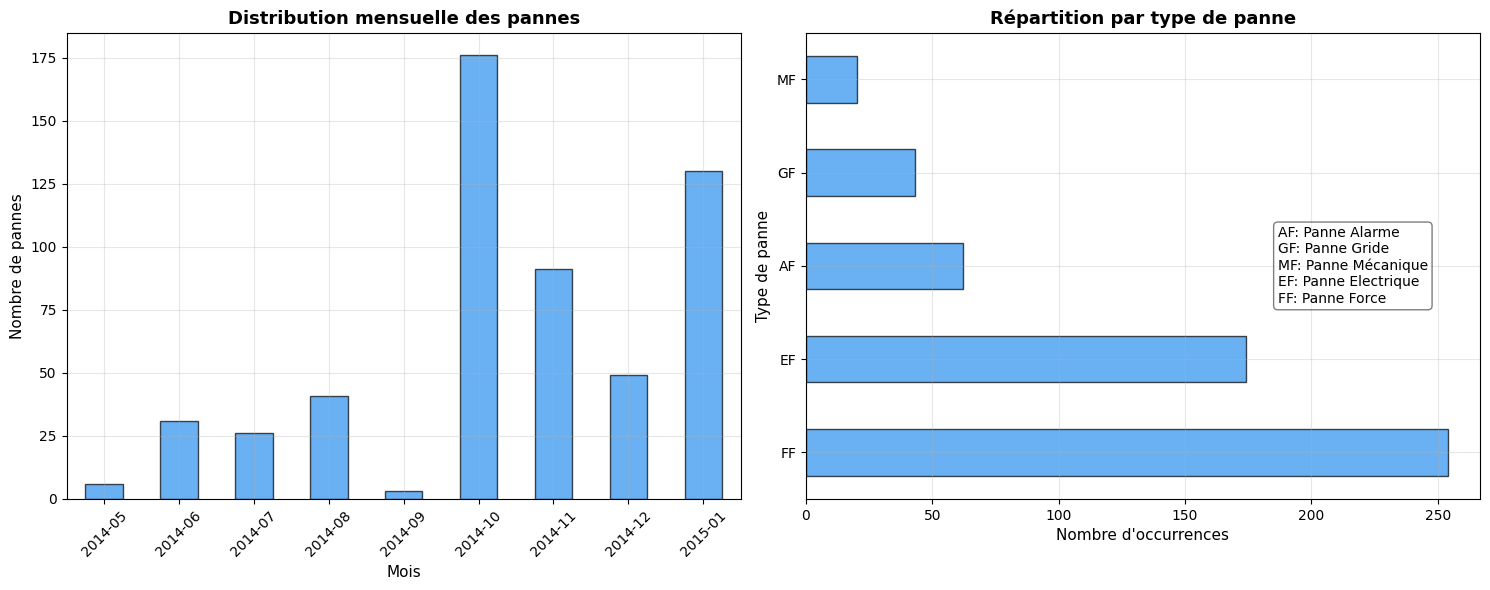

In [33]:

# Créer un dictionnaire pour mapper les codes aux descriptions
fault_labels = {
    'AF': 'Panne Alarme',
    'GF': 'Panne Gride',
    'MF': 'Panne Mécanique',
    'EF': 'Panne Electrique',
    'FF': 'Panne Force',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_fault['DateTime'] = pd.to_datetime(df_fault['DateTime'])

# Distribution temporelle des pannes
pannes_par_mois = df_fault.groupby(df_fault['DateTime'].dt.to_period('M')).size()
pannes_par_mois.plot(kind='bar', ax=axes[0], color="#2b90ee", alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution mensuelle des pannes', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mois', fontsize=11)
axes[0].set_ylabel('Nombre de pannes', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

#  Types de pannes 

legend_text = '\n'.join([f'{code}: {desc}' for code, desc in fault_labels.items()])

fault_counts = df_fault['Fault'].value_counts()
fault_counts.plot(kind='barh', ax=axes[1], color="#2b90ee", alpha=0.7, edgecolor='black')
axes[1].set_title('Répartition par type de panne', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nombre d\'occurrences', fontsize=11)
axes[1].set_ylabel('Type de panne', fontsize=11) 
axes[1].text(0.7, 0.5, legend_text, 
         transform=axes[1].transAxes,
         fontsize=10,
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 4. Preparation of data

### 4.1 Filtering real failures

In [ ]:
def is_real_fault(category):
    """Identifie si c'est une vraie panne nécessitant intervention"""
    fault_categories = [
        'Grid/Power Fault',
        'Electrical Fault',
        'Mechanical Fault',
        'System/Communication Fault'
    ]
    return category in fault_categories

df_status['Is_Real_Fault'] = df_status['Category'].apply(is_real_fault)


In [39]:
real_faults = df_status['Is_Real_Fault'].sum()
total = len(df_status)

print(f"\n Événements NORMAUX: {total - real_faults} ({((total-real_faults)/total)*100:.1f}%)")

print(f"\n VRAIES PANNES: {real_faults} ({(real_faults/total)*100:.1f}%)")

# Détail des vraies pannes
print("\n Détail des VRAIES PANNES par type:")
fault_details = df_status[df_status['Is_Real_Fault'] == True]['Category'].value_counts()
for cat, count in fault_details.items():
    pct = (count / real_faults) * 100
    print(f"   {cat:30s}: {count:4d} ({pct:5.1f}%)")


 Événements NORMAUX: 1609 (87.0%)

 VRAIES PANNES: 240 (13.0%)

 Détail des VRAIES PANNES par type:
   Grid/Power Fault              :  189 ( 78.8%)
   System/Communication Fault    :   28 ( 11.7%)
   Electrical Fault              :   16 (  6.7%)
   Mechanical Fault              :    7 (  2.9%)


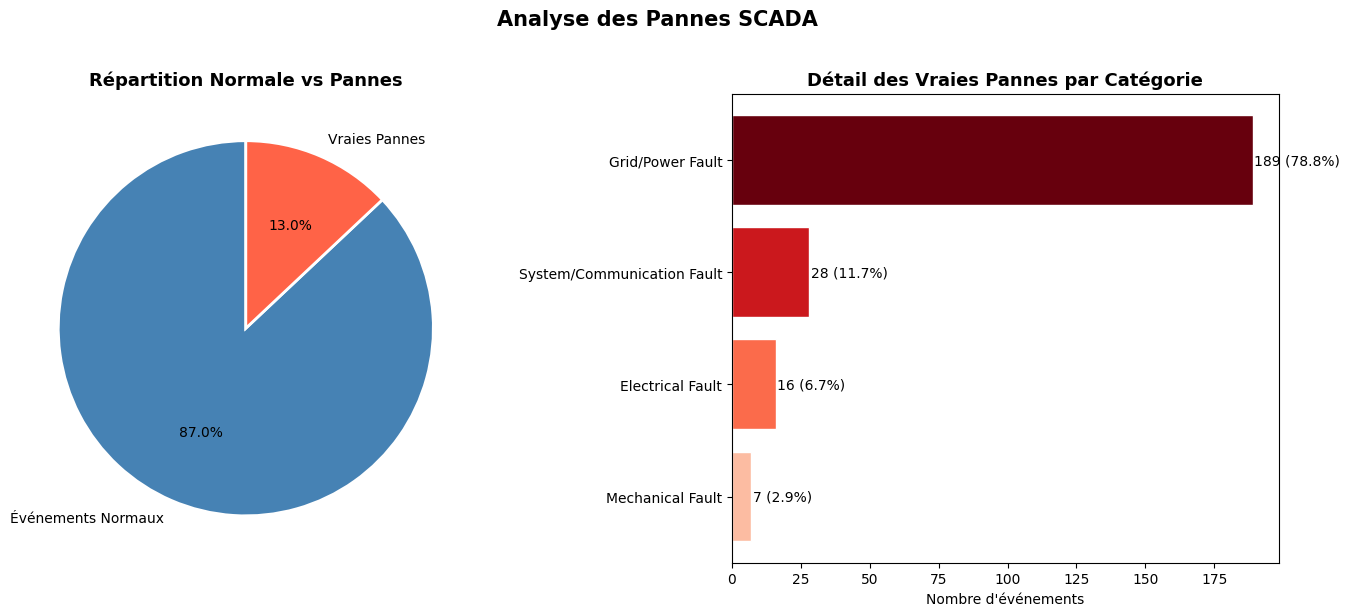

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Graphe 1 : Normal vs Vraies Pannes ──
labels_1 = ['Événements Normaux', 'Vraies Pannes']
values_1 = [total - real_faults, real_faults]
colors_1 = ['steelblue', 'tomato']

axes[0].pie(
    values_1,
    labels=labels_1,
    colors=colors_1,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title("Répartition Normale vs Pannes", fontsize=13, fontweight='bold')

# ── Graphe 2 : Détail des vraies pannes par catégorie ──
fault_details = df_status[df_status['Is_Real_Fault'] == True]['Category'].value_counts()

colors_2 = plt.cm.Reds_r([i / len(fault_details) for i in range(len(fault_details))])

bars = axes[1].barh(
    fault_details.index,
    fault_details.values,
    color=colors_2,
    edgecolor='white'
)

# Ajouter les valeurs + pourcentages sur les barres
for bar, val in zip(bars, fault_details.values):
    pct = (val / real_faults) * 100
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val} ({pct:.1f}%)',
        va='center', fontsize=10
    )

axes[1].set_title("Détail des Vraies Pannes par Catégorie", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Nombre d'événements")
axes[1].invert_yaxis()  # catégorie la plus fréquente en haut

plt.suptitle("Analyse des Pannes SCADA", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 - Projection of failures into SCADA

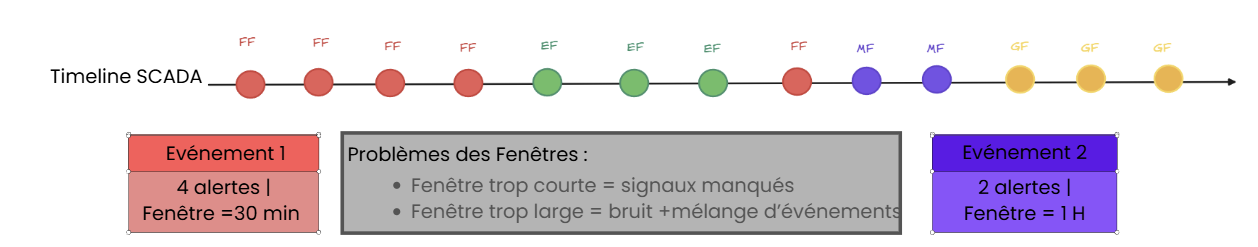

In [ ]:
img = Image.open("/mnt/c/Users/nouha/Documents/projet_fin_detude/maintenance_predictive/images/scada_projection.png")
img

In [41]:
# regroupement les alarmes dans un evemenent => panne avant la projection

def identify_failure_events(fault_df, min_gap_hours=2):
    
    # Garder SEULEMENT les enregistrements de panne
    # pas les resets, pas les normaux
    fault_only = fault_df[
        fault_df['Fault'].isin(['GF', 'MF', 'EF', 'AF', 'FF'])
    ].copy()
    
    fault_only['DateTime'] = pd.to_datetime(fault_only['DateTime'])
    fault_only = fault_only.sort_values('DateTime').reset_index(drop=True)
    
    fault_only['time_since_last'] = fault_only['DateTime'].diff()
    
    fault_only['is_new_event'] = (
        (fault_only['time_since_last'] > pd.Timedelta(hours=min_gap_hours)) |
        (fault_only['time_since_last'].isna())
    )
    
    fault_only['event_id'] = fault_only['is_new_event'].cumsum()
    
    events = fault_only.groupby('event_id').agg({
        'DateTime': ['first', 'last', 'count'],
        'Fault': [
            ('fault_start', lambda x: x.iloc[0]),
            ('fault_end',   lambda x: x.iloc[-1]),
        ]
    }).reset_index()
    
    events.columns = [
        'event_id', 'start_time', 'end_time', 
        'nb_records', 'fault_start', 'fault_end'
    ]
    
    events['duration_hours'] = (
        (events['end_time'] - events['start_time'])
        .dt.total_seconds() / 3600
    )
    
    return events

events_df = identify_failure_events(df_fault, min_gap_hours=2)
print(f"\nÉvénements identifiés : {len(events_df)}")


Événements identifiés : 73


In [42]:
events_df.head()

,event_id,start_time,end_time,nb_records,fault_start,fault_end,duration_hours
0,1,2014-05-14 14:39:44,2014-05-14 15:30:56,6,GF,GF,0.853333
1,2,2014-06-04 08:09:20,2014-06-04 08:20:00,2,MF,MF,0.177778
2,3,2014-06-04 17:00:32,2014-06-04 17:00:32,1,MF,MF,0.000000
3,4,2014-06-05 15:50:08,2014-06-05 17:41:04,2,MF,FF,1.848889
4,5,2014-06-08 23:50:08,2014-06-09 00:09:20,5,AF,MF,0.320000


### 4.3 Impact of Inter-Failure Time

In [43]:
def compute_gap_results(fault_df, test_gaps=[0.25, 0.5, 1, 2, 4, 6]):
    """
    retourner un DataFrame avec le nb d'événements pour chaque gap testé
    """
    results = []
    for gap in test_gaps:
        results.append({'gap_hours': gap, 'nb_events': len(identify_failure_events(fault_df, min_gap_hours=gap))})
    return pd.DataFrame(results)
result=compute_gap_results(df_fault,test_gaps=[0.25, 0.5, 1, 2, 4, 6])
result

,gap_hours,nb_events
0,0.25,120
1,0.50,103
2,1.00,87
3,2.00,73
4,4.00,61
5,6.00,59


In [49]:
def recommend_gap(fault_df):
    """Calcule le gap recommandé à partir des percentiles des gaps observés."""
    fault_sorted = fault_df.sort_values('DateTime').copy()
    fault_sorted['gap_hours'] = fault_sorted['DateTime'].diff().dt.total_seconds() / 3600
    gaps = fault_sorted['gap_hours'].dropna().values

    p75 = np.percentile(gaps, 75) * 60  # minutes
    p90 = np.percentile(gaps, 90) * 60

    print("\n" + "=" * 70)
    print(f"   75% des gaps sont ≤ {p75:.0f} minutes ({p75/60:.2f}h)")
    print(f"   90% des gaps sont ≤ {p90:.0f} minutes ({p90/60:.2f}h)")

    if p75 < 30:
        recommended, msg = 0.5, "Alerts are very close together"
    elif p75 < 60:
        recommended, msg = 1, "Alerts are moderately spaced"
    else:
        recommended, msg = 2, "Alerts are more spread out"

    print(f"\n   RECOMMANDATION : gap = {recommended}h → {msg}")
    return recommended, gaps


   75% des gaps sont ≤ 11 minutes (0.18h)
   90% des gaps sont ≤ 441 minutes (7.36h)

   RECOMMANDATION : gap = 0.5h → Alerts are very close together


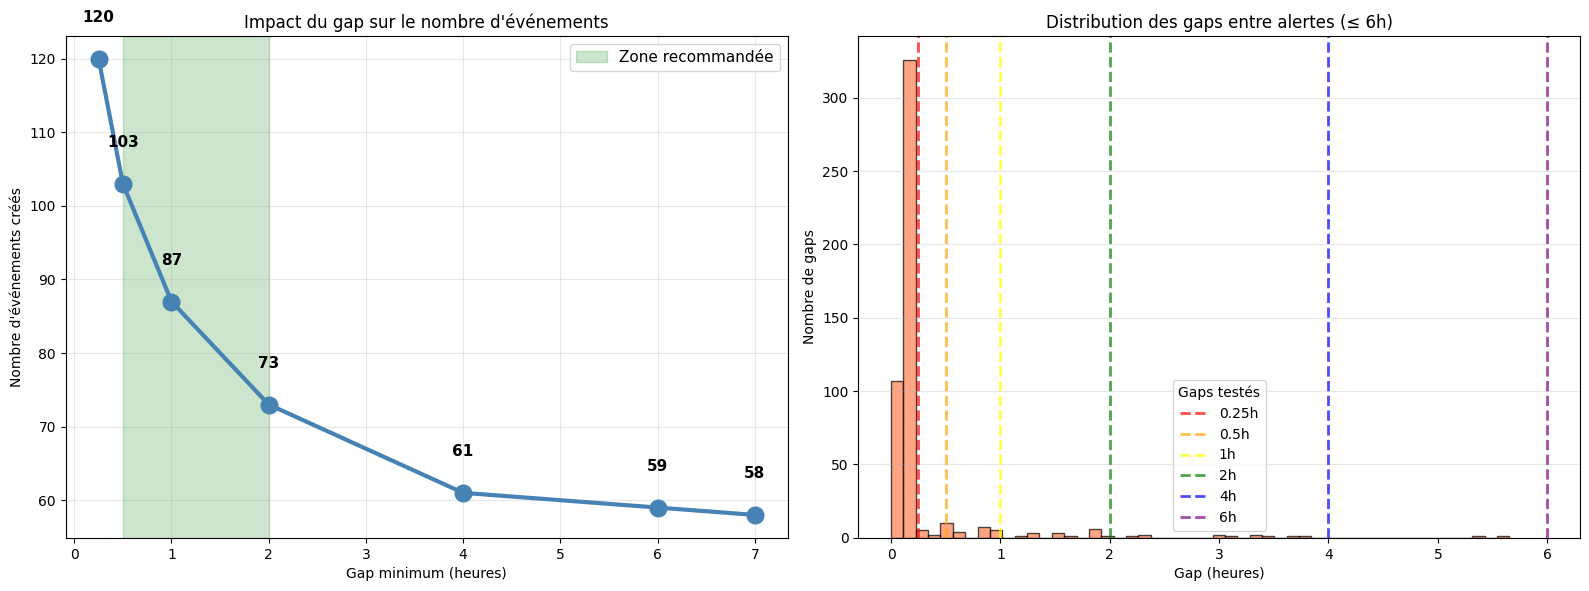


SUMMARY: NUMBER OF EVENTS BASED ON GAP
 gap_hours  nb_events
      0.25        120
      0.50        103
      1.00         87
      2.00         73
      4.00         61
      6.00         59
      7.00         58


In [50]:
def visualize_gap_impact(fault_df, test_gaps=[0.25, 0.5, 1, 2, 4, 6]):
    """Orchestre le calcul, la recommandation et les graphiques."""

    results_df             = compute_gap_results(fault_df, test_gaps)
    recommended, gaps_obs  = recommend_gap(fault_df)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # — Plot 1 : nb événements vs gap —
    ax1.plot(results_df['gap_hours'], results_df['nb_events'],
             marker='o', linewidth=3, markersize=12, color='steelblue')
    for _, row in results_df.iterrows():
        ax1.text(row['gap_hours'], row['nb_events'] + 5,
                 f"{int(row['nb_events'])}", ha='center',
                 fontsize=11, fontweight='bold')
    ax1.axvspan(0.5, 2, alpha=0.2, color='green', label='Zone recommandée')
    ax1.set(xlabel='Gap minimum (heures)', ylabel="Nombre d'événements créés",
            title="Impact du gap sur le nombre d'événements")
    ax1.legend(fontsize=11)
    ax1.grid(alpha=0.3)

    # — Plot 2 : distribution des gaps observés —
    gaps_plot = gaps_obs[gaps_obs <= 6]
    ax2.hist(gaps_plot, bins=50, color='coral', alpha=0.7, edgecolor='black')
    colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']
    for gap_h, color in zip(test_gaps, colors):
        ax2.axvline(gap_h, color=color, linestyle='--',
                    linewidth=2, label=f'{gap_h}h', alpha=0.7)
    ax2.set(xlabel='Gap (heures)', ylabel='Nombre de gaps',
            title='Distribution des gaps entre alertes (≤ 6h)')
    ax2.legend(title='Gaps testés', fontsize=10)
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('choix_gap_optimal.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n" + "=" * 70)
    print("SUMMARY: NUMBER OF EVENTS BASED ON GAP")
    print("=" * 70)
    print(results_df.to_string(index=False))

    return results_df, recommended


# ── Appel ───────────────────────────────────────────────────────────────────
results, recommended_gap = visualize_gap_impact(
    df_fault, test_gaps=[0.25, 0.5, 1, 2, 4, 6, 7]
)

### 4.3 Projection of Events into SCADA

In [ ]:
df_scada['DateTime'] = pd.to_datetime(df_scada['DateTime'])
df_scada['target'] = 0 # creer une colonne target

for _, event in events_df.iterrows():

    # Panne → target = 2
    mask_panne = (
        (df_scada['DateTime'] >= event['start_time']) &
        (df_scada['DateTime'] <= event['end_time'])
    )
    df_scada.loc[mask_panne, 'target'] = 2

    # Pré-panne → target = 1 (2 h avant, seulement si Normal)
    pre_start = event['start_time'] - pd.Timedelta(hours=2)
    mask_pre = (
        (df_scada['DateTime'] >= pre_start) &
        (df_scada['DateTime'] < event['start_time']) &
        (df_scada['target'] == 0)
    )
    df_scada.loc[mask_pre, 'target'] = 1

# ── Résultats ─────────────────────────────────────────────
print(f"Normal    (0) : {(df_scada['target']==0).sum():,}")
print(f"Pré-failure (1) : {(df_scada['target']==1).sum():,}")
print(f"Failure     (2) : {(df_scada['target']==2).sum():,}")
print(f"Total         : {len(df_scada):,}")
ratio = (df_scada['target'] == 0).sum() / (df_scada['target'] == 1).sum()
print(f"\nImbalance (Normal:Pre-failure): {ratio:.1f}:1")

Normal    (0) : 47,588
Pré-panne (1) : 861
Panne     (2) : 578
Total         : 49,027

Imbalance (Normal:Pre-failure): 55.3:1


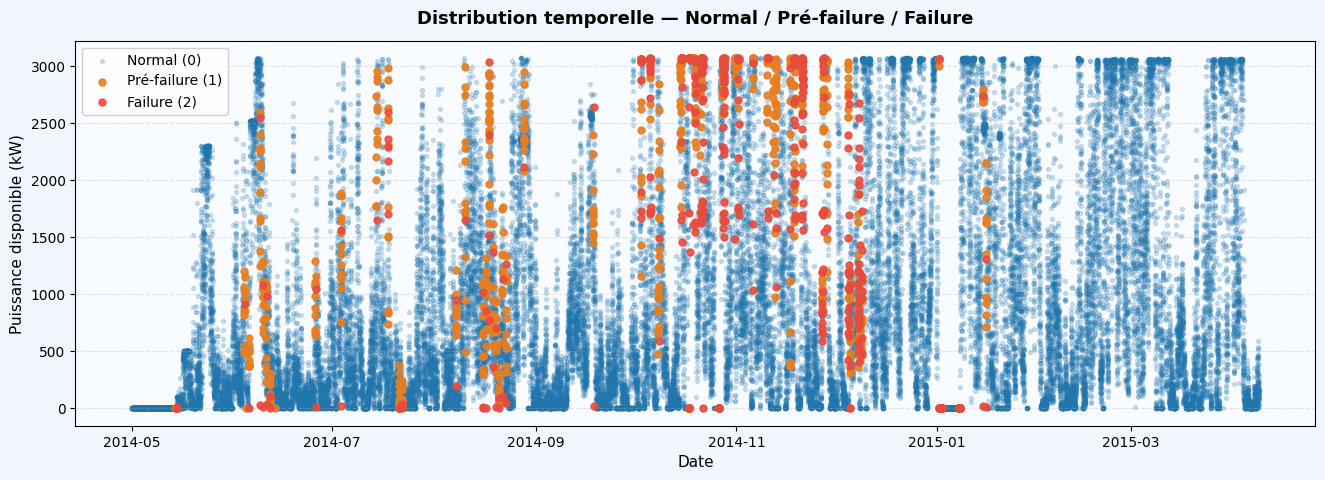

In [53]:
# visulaiser les points de target sur la puissance
df_scada['DateTime'] = pd.to_datetime(df_scada['DateTime'])

fig, ax = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#F0F6FC')
ax.set_facecolor('#F8FBFF')

#  Normal 
ax.scatter(
    df_scada[df_scada['target']==0]['DateTime'],
    df_scada[df_scada['target']==0]['WEC: ava. Power'],
    color='#2176AE', alpha=0.2, s=8, label='Normal (0)'
)

# Pré-panne 
ax.scatter(
    df_scada[df_scada['target']==1]['DateTime'],
    df_scada[df_scada['target']==1]['WEC: ava. Power'],
    color='#E67E22', alpha=0.9, s=25, zorder=3, label='Pré-failure (1)'
)

#  Panne 
ax.scatter(
    df_scada[df_scada['target']==2]['DateTime'],
    df_scada[df_scada['target']==2]['WEC: ava. Power'],
    color='#E74C3C', alpha=0.9, s=25, zorder=4, label='Failure (2)'
)

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Puissance disponible (kW)", fontsize=11)
ax.set_title("Distribution temporelle — Normal / Pré-failure / Failure",
             fontsize=13, fontweight='bold', pad=12)

n_normal  = (df_scada['target']==0).sum()
n_pre     = (df_scada['target']==1).sum()
n_panne   = (df_scada['target']==2).sum()


ax.legend( fontsize=10,
          loc='upper left', framealpha=0.9)

ax.grid(axis='y', alpha=0.3, linestyle='--')

### 4.4 Results

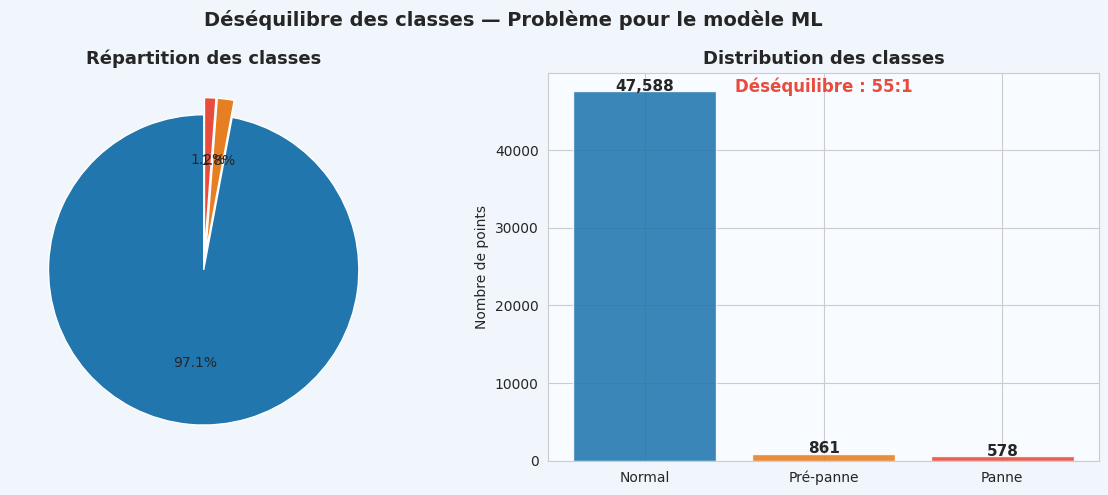

In [54]:
# Répartition des classes
temp = df_scada['target'].value_counts().sort_index()
labels = ['Normal', 'Pré-panne', 'Panne']
colors = ['#2176AE', '#E67E22', '#E74C3C']

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#F0F6FC')

axes[0].pie(             
    temp,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.09, 0.09)
)
axes[0].set_title('Répartition des classes', fontsize=13, fontweight='bold')

bars = axes[1].bar(labels, temp.values, color=colors,
                   edgecolor='white', alpha=0.88)
axes[1].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nombre de points')
axes[1].set_facecolor('#F8FBFF')

for bar, val in zip(bars, temp.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{val:,}',
        ha='center', fontweight='bold', fontsize=11
    )

axes[1].text(
    0.5, 0.95,
    f'Déséquilibre : {temp.values[0]/temp.values[1]:.0f}:1',
    transform=axes[1].transAxes,
    ha='center', color='#E74C3C',
    fontweight='bold', fontsize=12
)

plt.suptitle('Déséquilibre des classes — Problème pour le modèle ML',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('desequilibre.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 save the dataset

In [55]:
df_scada.to_csv("df_final.csv", index=False)